# Test WebMap.print() function

In [1]:
# When using `geosaurus_dev_env` conda env

# import sys
# sys.path.append('/Users/atma6951/Documents/code/geosurus/geosaurus/src')

In [1]:
from arcgis.gis import GIS
from arcgis.mapping import WebMap, export_map, get_layout_templates
from arcgis.geometry import Point
from arcgis.features import FeatureSet, FeatureCollection, Feature
from arcgis.geocoding import geocode

import json
import requests
from IPython.display import Image
import matplotlib.pyplot as plt

In [2]:
gis = GIS()

In [3]:
pt1 = Point([-117.18, 34.05])
ft = Feature(pt1, attributes={'name':'Redlands'})
fset = FeatureSet([ft])
fc = FeatureCollection.from_featureset(fset)
fc

<FeatureCollection>

In [4]:
redlands_extent = {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'xmin': -13074746.000753032,
 'ymin': 4020957.451106308,
 'xmax': -13014666.49652086,
 'ymax': 4051532.26242039}

ca_extent = {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'xmin': -15199645.40582486,
 'ymin': 3395607.5273594954,
 'xmax': -11354557.134968376,
 'ymax': 5352395.451459487}

In [23]:
map2 = gis.map('California')
map2

MapView(layout=Layout(height='400px', width='100%'))

In [24]:
map2.extent

{'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'xmin': -15199645.40582486,
 'ymin': 3395607.5273594954,
 'xmax': -11354557.134968376,
 'ymax': 5352395.451459487}

In [63]:
map2.scale

36111.909643

In [69]:
map2.rotation

347.5124170764584

## 1 - File formats - JPG, PNG, PDF & Extent

In [11]:
wm1 = WebMap()
wm1.basemap = 'streets-vector'

In [12]:
wm1.add_layer(fc)

True

### JPG

In [13]:
%%time
print_jpg = wm1.print(file_format='JPG', extent=redlands_extent)
print_jpg

CPU times: user 27.3 ms, sys: 4.04 ms, total: 31.4 ms
Wall time: 3.92 s


'https://utility.arcgisonline.com/arcgis/rest/directories/arcgisoutput/Utilities/PrintingTools_GPServer/x_____xASzp725fW7PZZx-k09lPAA..x_____x_ags_79062694-68a8-11eb-8502-22000aee1b37.jpg'

### PNG32

In [52]:
%%time
print_png = wm1.print(file_format='PNG32', extent=redlands_extent)

CPU times: user 6.36 ms, sys: 1.98 ms, total: 8.34 ms
Wall time: 3.05 s


Text(0.5, 1.0, 'JPG')

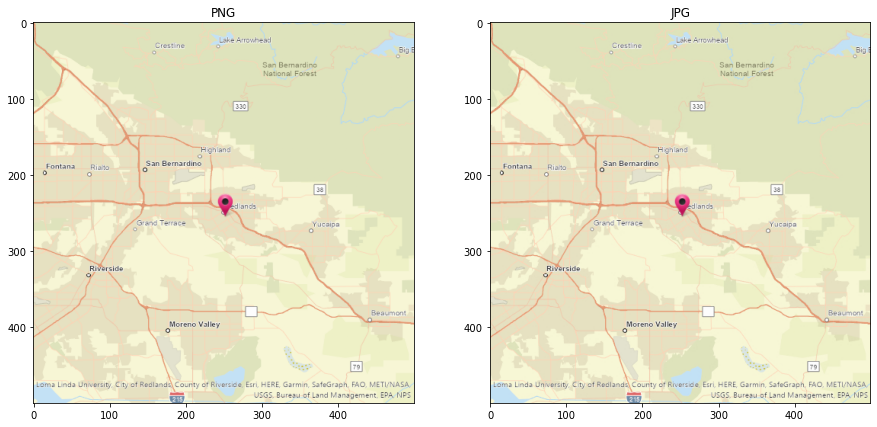

In [57]:
fig, ax = plt.subplots(1,2, figsize=(15,10))
ppng = plt.imread(print_png)
ax[0].imshow(ppng)
ax[0].set_title('PNG');

pjpg = plt.imread(print_jpg, format='JPG')
ax[1].imshow(pjpg)
ax[1].set_title('JPG')

### PDF

In [33]:
%%time
print_pdf = wm1.print(file_format='PDF', extent=ca_extent)

CPU times: user 17.2 ms, sys: 2.59 ms, total: 19.8 ms
Wall time: 3.76 s


In [35]:
print_pdf

'https://utility.arcgisonline.com/arcgis/rest/directories/arcgisoutput/Utilities/PrintingTools_GPServer/x_____xcrrXbjTnBE_K-qq1UFP60Q..x_____x_ags_12293b46-680a-11eb-991f-22000a9ddd1a.pdf'

## 2 Change DPI

In [58]:
print_150dpi = wm1.print(file_format='JPG', extent=ca_extent, dpi=150)
print_300dpi = wm1.print(file_format='JPG', extent=ca_extent, dpi=300)

Text(0.5, 1.0, '300 DPI')

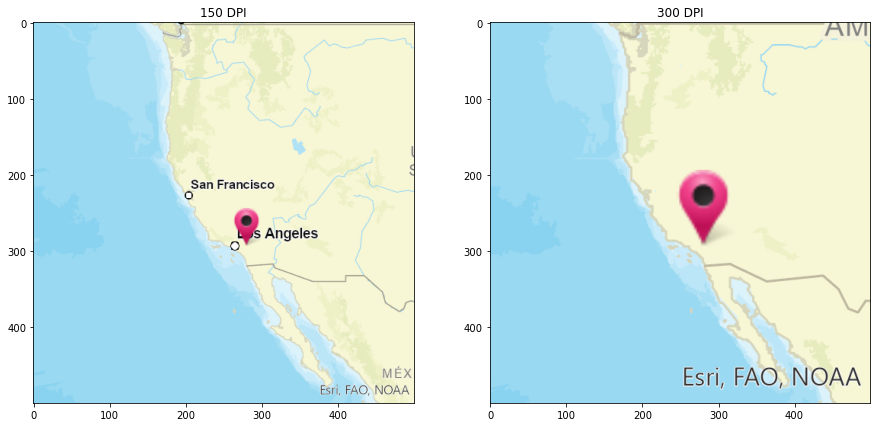

In [59]:
fig, ax = plt.subplots(1,2, figsize=(15,10))
p1 = plt.imread(print_150dpi, format='JPG')
ax[0].imshow(p1)
ax[0].set_title('150 DPI');

p1 = plt.imread(print_300dpi, format='JPG')
ax[1].imshow(p1)
ax[1].set_title('300 DPI')

## 3 Change map image dimensions

In [60]:
%%time
print_300x300 = wm1.print(file_format='JPG', 
                          extent=ca_extent, output_dimensions=[300,300])
print_600x400 = wm1.print(file_format='JPG', 
                          extent=ca_extent, output_dimensions=[600,400])

CPU times: user 34.9 ms, sys: 4.36 ms, total: 39.2 ms
Wall time: 5.56 s


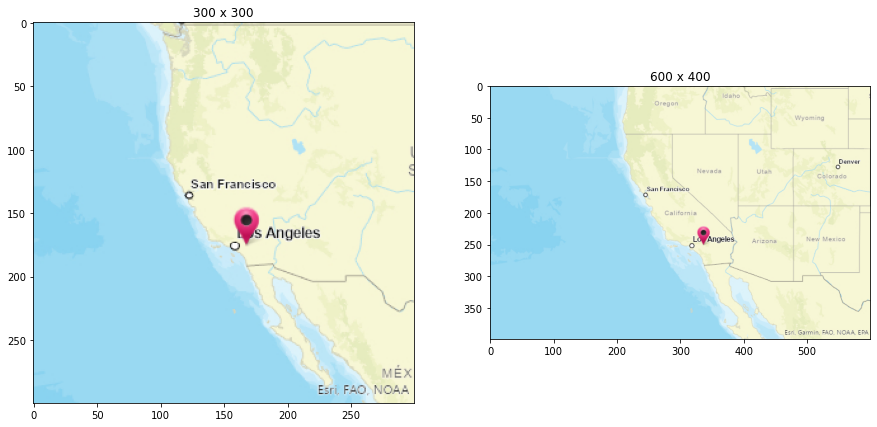

In [62]:
fig, ax = plt.subplots(1,2, figsize=(15,10))
p1 = plt.imread(print_300x300, format='JPG')
ax[0].imshow(p1)
ax[0].set_title('300 x 300');

p1 = plt.imread(print_600x400, format='JPG')
ax[1].imshow(p1)
ax[1].set_title('600 x 400');

## 4. Change map scale

In [66]:
%%time
print_36k = wm1.print(file_format='JPG', 
                          extent=redlands_extent, scale=36000)

print_150k = wm1.print(file_format='JPG', 
                          extent=redlands_extent, scale=150000)

CPU times: user 21.7 ms, sys: 3.78 ms, total: 25.5 ms
Wall time: 6.36 s


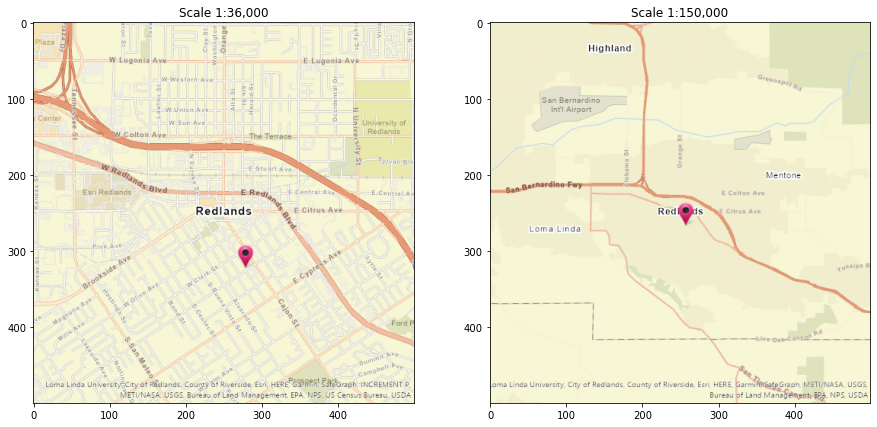

In [67]:
fig, ax = plt.subplots(1,2, figsize=(15,10))
p1 = plt.imread(print_36k, format='JPG')
ax[0].imshow(p1)
ax[0].set_title('Scale 1:36,000');

p1 = plt.imread(print_150k, format='JPG')
ax[1].imshow(p1)
ax[1].set_title('Scale 1:150,000');

## 5. Rotation

In [70]:
%%time
print_90e = wm1.print(file_format='JPG', 
                          extent=redlands_extent, rotation=90)

print_180s = wm1.print(file_format='JPG', 
                          extent=redlands_extent, rotation=180)

CPU times: user 22.1 ms, sys: 3.75 ms, total: 25.8 ms
Wall time: 5 s


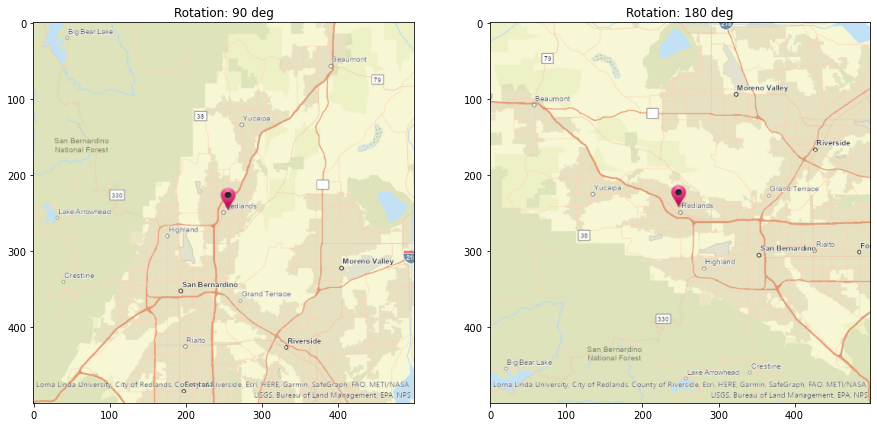

In [71]:
fig, ax = plt.subplots(1,2, figsize=(15,10))
p1 = plt.imread(print_90e, format='JPG')
ax[0].imshow(p1)
ax[0].set_title('Rotation: 90 deg');

p1 = plt.imread(print_180s, format='JPG')
ax[1].imshow(p1)
ax[1].set_title('Rotation: 180 deg');

## 6. Layouts - A4, Letter

In [18]:
[i['layoutTemplate'] for i  in get_layout_templates()]

['A3 Landscape',
 'A3 Portrait',
 'A4 Landscape',
 'A4 Portrait',
 'Letter ANSI A Landscape',
 'Letter ANSI A Portrait',
 'Tabloid ANSI B Landscape',
 'Tabloid ANSI B Portrait']

In [84]:
%%time
print_a4land = wm1.print(file_format='JPG', 
                          extent=redlands_extent, layout_template='A4 Landscape')

print_let_port = wm1.print(file_format='JPG', 
                          extent=redlands_extent, layout_template='Letter ANSI A Portrait')

CPU times: user 21.8 ms, sys: 3.8 ms, total: 25.6 ms
Wall time: 10.5 s


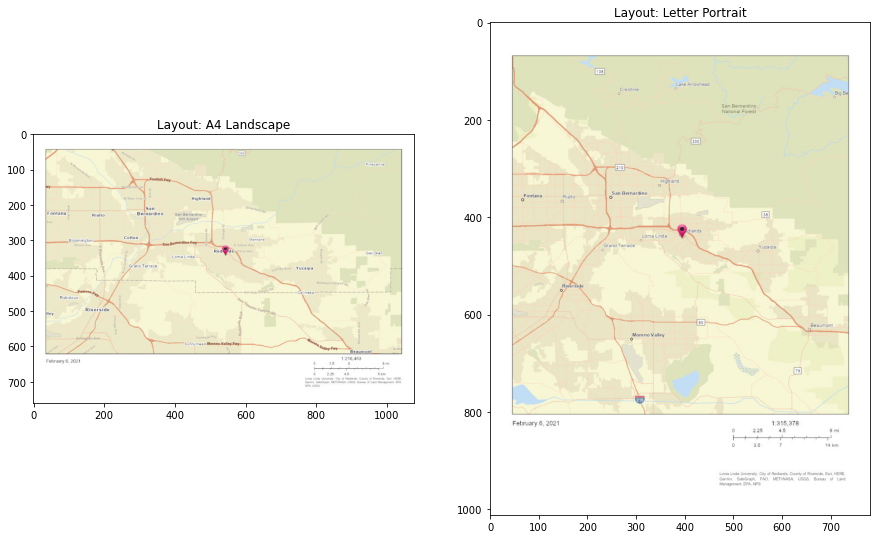

In [87]:
fig, ax = plt.subplots(1,2, figsize=(15,10))
p1 = plt.imread(print_a4land, format='JPG')
ax[0].imshow(p1)
ax[0].set_title('Layout: A4 Landscape');

p1 = plt.imread(print_let_port, format='JPG')
ax[1].imshow(p1)
ax[1].set_title('Layout: Letter Portrait');

## 7. Complex map

In [6]:
wm_item = gis.content.get('c6ba9c02006948b9bdc1d66436fa5d29')
complex_wm = WebMap(wm_item)

In [16]:
%%time
print_a4land_c = complex_wm.print(file_format='JPG', 
                          extent=ca_extent, layout_template='A4 Landscape')

CPU times: user 11 ms, sys: 2.36 ms, total: 13.3 ms
Wall time: 7.85 s


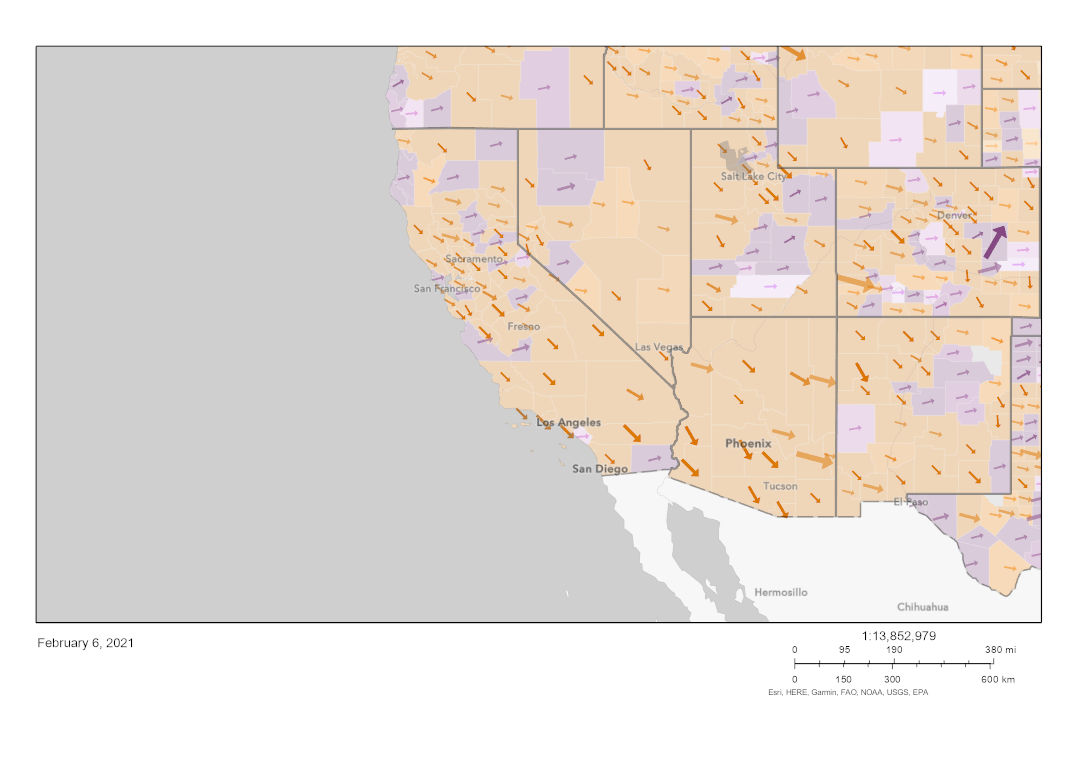

In [17]:
Image(print_a4land_c)

## Download image file

In [21]:
import requests

In [32]:
with requests.get(print_png) as resp:
    with open('./output_file.png', 'wb') as file_handle:
        file_handle.write(resp.content)